In [34]:
# pip install jenkspy

In [35]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import jenkspy

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


pd.set_option('display.max_columns', None)

In [36]:
# ____________________________________________________________________________________________________________
# Loading the previously validated dataset. See more in data_load folder of the repository
# ____________________________________________________________________________________________________________

data_ldn = pd.read_csv(
    "data_load/final_output.csv", na_values=["NULL", "null", "None", "", "[]", "NaN"])
data_ldn_exstg = data_ldn[data_ldn["completed"] == "Completed"].drop(axis=1, columns=['completed']) #taking only the data centres that were built
data_ldn_exstg = data_ldn_exstg.sort_values(by="data_centre_since", ascending=True)
data_ldn_exstg.head(1)

,lpa_name,uprn,decision_date,id,postcode,description,last_updated,lpa_app_no,url_planning_app,application_details_site_area,is_full_planning,geometry_point,geometry,notes,enterprise,current_occupier,website,address,data_centre_since,preapp_started,b8_no_storeys,b8_max_height_m,b8_gia_sqm,other_use_classes_present_within_b8_building,b8_total_staff_fte,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate
0,Barking & Dagenham,100101450,12/09/2018,Barking_&_Dagenham-18_00161_FUL,RM10 7XS,Erection of two data centre buildings (Use Cla...,2025-03-20T18:57:14.569+00:00,18/00161/FUL,https://online-befirst.lbbd.gov.uk/planning/in...,7.54,True,POINT (-7.55716 49.766807),"POLYGON ((550745 185653.291, 550760.214 185448...","Construction of 2 No. Data Centres (9,263 and ...",False,NTT Data Centre,https://services.global.ntt/en-us/services-and...,London East Business And Technical Park Yewtre...,2025.0,2017,3.0,17300.0,52797.3,NaN,150.0,14.0,NaN,30.0,66.0,40.0,NaN,62.0,2.42,62.0


The dataset includes built data centres of various sizes. Those under construction are excluded as we can't verify their real employment before operational stage.

In [37]:
data_ldn_exstg.describe()

,application_details_site_area,data_centre_since,b8_no_storeys,b8_max_height_m,b8_gia_sqm,b8_total_staff_fte,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate
count,33.000000,43.000000,35.000000,25.000000,38.000000,21.000000,4.000000,3.000000,4.000000,3.000000,5.000000,1.0,8.000000,4.000000,7.000000
mean,1.128070,2007.860465,4.057143,710.644920,12034.321979,73.904762,10.750000,4.333333,9.750000,31.333333,11.600000,13.0,37.750000,2.990000,28.857143
std,1.509598,9.030587,3.324976,3456.157457,15872.687514,75.262809,3.947573,2.886751,13.524669,30.615900,16.009372,NaN,33.225421,1.134578,23.448017
min,0.009000,1979.000000,1.000000,4.400000,24.000000,5.000000,5.000000,1.000000,2.000000,8.000000,1.000000,13.0,7.000000,1.970000,7.000000
25%,0.154000,2001.000000,2.000000,7.800000,2130.750000,20.000000,10.250000,3.500000,2.750000,14.000000,5.000000,13.0,13.000000,2.307500,11.000000
50%,0.498300,2007.000000,2.000000,13.500000,4752.000000,45.000000,12.000000,6.000000,3.500000,20.000000,6.000000,13.0,25.500000,2.710000,20.000000
75%,1.749000,2015.500000,5.500000,29.753000,15601.500000,100.000000,12.500000,6.000000,10.500000,43.000000,6.000000,13.0,60.500000,3.392500,45.500000
max,7.540000,2025.000000,13.000000,17300.000000,69829.000000,262.000000,14.000000,6.000000,30.000000,66.000000,40.000000,13.0,100.000000,4.570000,62.000000


> **Status and ownership**
> -  Unique PA reference - **id**
> -  DC postcode - **postcode**
> -  DC address - **address**
> -  Category col indicating the state of completion - **completed**
> -  Date when DC was operational for the first time in this building. Note the size and staff numbers reflect the current situation, not when DC opened - **data_centre_since**
> -  Year/date when the first pre-app stage document was received - **preapp_started**
> -  Boolean col indicating whether DC is enterprise or any other type - **enterprise**
> -  Current owner/occupier of DC - **current_occupier**
> -  Company website - **website**
> -  Unique property reference - **uprn**
> -  Local authority (borough) name - **lpa_name**. Note a few of DC in Slough were manually added as the information became available. Slough DC will only be used for size and staff analysis, not for the spatial clustering

> **Attached planning application**
> -  PA code (contains repetitions with unique other columns, use id for cross-comparing) - **lpa_app_no**
> -  PA webpage - **url_planning_app**
> -  PA decision date - **decision_date**. Note it does not always represent a moment when the DC was created 
> -  PA description. Note it sometimes refers to PAs with additions to DC, not its development - **description**
> -  Notes about the application and current use - **notes**
> -  PA system update - **last_updated**
> -  Helper column with the data source – **is_full_planning**

> **Spatial parameters**
> -  Gross internal area of the DC use - **b8_gia_sqm**
> -  Site area in hectares – **application_details_site_area**
> -  Number of storeys in the DC building, or stories occupied by the DC if other uses present - **b8_no_storeys**
> -  Height of the DC in meters **b8_max_height_m**
> -  List of other uses within the building with the DC – **other_use_classes_present_within_b8_building**
> -  Geometry cols - **geometry_point, geometry**

> **Employment data**
> -  Total staff number in the DC - **b8_total_staff_fte**
> -  N of security staff - **security_staff**
> -  N of engineering/technical staff - **site_engineers_staff**
> -  N of administrative staff - **managers_staff**
> -  N of cleaning/housekeeping staff - **cleaners_staff**
> -  N of visitor staff, typically client technicians - **visitor_staff_not_on_site**
> -  N of staff working within one cluster, if more than one DC is in the area. Mostly refers to admin/technicians - **cluster_staff_not_on_site**
> -  N of staff present on site per day - **b8_employees_at_a_day**

In [392]:
# ____________________________________________________
# Helper function
# ____________________________________________________

def make_transparent(color, alpha=0.3):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color


notes_colour = "black"
labels_colour = "grey"

In [238]:
# # -------------------------------------
# # Explicit categories (boolean)
# # -------------------------------------
# categories = [False, True]

# palette = px.colors.qualitative.Plotly
# color_map = {
#     False: palette[0],
#     True: palette[1],
# }

# # -------------------------------------
# # Build figure
# # -------------------------------------
# fig = go.Figure()

# for cat in categories:
#     subset = data_ldn_date[data_ldn_date['enterprise'] == cat]

#     # Left half-violin (transparent)
#     fig.add_trace(go.Violin(
#         y=[cat] * len(subset),                     # ← critical
#         x=subset['b8_total_staff_fte'],
#         orientation='h',
#         side='negative',
#         points=False,
#         bandwidth=3,
#         width=0.4,
#         line=dict(width=0),
#         fillcolor=make_transparent(color_map[cat], alpha=0.3),
#         showlegend=False,
#     ))

#     # Right half-violin (solid + points + box)
#     fig.add_trace(go.Violin(
#         y=[cat] * len(subset),                     # ← critical
#         x=subset['b8_total_staff_fte'],
#         orientation='h',
#         side='positive',
#         width=0.9,
#         line=dict(width=0),
#         points="all",
#         jitter=0.3,
#         pointpos=-0.4,
#         marker=dict(color='grey', size=3),
#         box_visible=True,
#         box_fillcolor='black',
#         box_line=dict(color='black', width=2),
#         box_width=0.1,
#         fillcolor=color_map[cat],
#         showlegend=False,
#     ))

# # -------------------------------------
# # Median arrows
# # -------------------------------------
# medians = (
#     data_ldn_date
#     .groupby('enterprise')['b8_total_staff_fte']
#     .median()
#     .reset_index()
# )

# fig.add_scatter(
#     x=medians['b8_total_staff_fte'],
#     y=medians['enterprise'],
#     mode='markers',
#     marker=dict(
#         symbol='circle',   # horizontal line
#         color='white',
#         size=8,
#         line=dict(width=2.5),
#     ),
#     showlegend=False,
# )

# # -------------------------------------
# # Layout
# # -------------------------------------
# fig.update_layout(
#     violinmode='overlay',
#     width=1000,
#     height=600,
#     xaxis=dict(
#         title="Total data centre staff (FTE)",
#         # range=[0, None],       
#     ),
#     yaxis=dict(
#         title=None,
#         tickvals=[False, True],  
#         ticktext=["Other", "Enterprise"],  # labels shown
#         categoryorder="array",
#         categoryarray=[False, True],  # explicit order
#         showgrid=False,
#     ),
#     template='plotly_white',

#     title=dict(
#         text=(
#             "<span style='font-size:24px; font-weight:700;'>"
#             "Distribution of staff numbers by data centre type"
#             "</span><br>"
#             "<span style='font-size:13px; font-weight:300; color:black;'>"
#             "Subtitle TBC"
#             "</span>"
#         ),
#         x=0.03,
#         xanchor="left",
#         y=0.97,
#         yanchor="top",
#     ),
#     margin=dict(t=60),
# )

# fig.show()

In [38]:
# ____________________________________________________________________________________________________________
# The dataset has a lot of NA values, and it will present an obstacle for clustering.
# My solution is to follow a stepwise approach to this study, and fill the NA where appropriate, once the basis for this is determined.
# ____________________________________________________________________________________________________________
data_ldn_exstg.isna().sum()

The dataset has quite a few NA valuer, and imputation is needed to analyse patterns. To adjust imputation for a specific data centre type, we need to perform segmentation. As power usage is not in this dataset, we will segment based on the GIA. Recent research by the House Of Commons outlines four DC types: 

- enterprise (operated by an organisation for internal purposes), 
- co-location (third party renting rack space to customers), 
- hyperscale (large facilities by major cloud providers), 
- AI (designed for high-performance computing).

Apart from operational, security and other differences, they can vary by GIA. Below we perform the segmentation using Jenks natural breaks. This method is appropriate for small, 1-dimentional data (GIA) with potentially unequal number of datapoints in each class, and skewed distributions (see chart below). The method optimizes for total intra-class variance, making the classes as homogeneous as possible. (hhttps://observablehq.com/@visionscarto/natural-breaks).

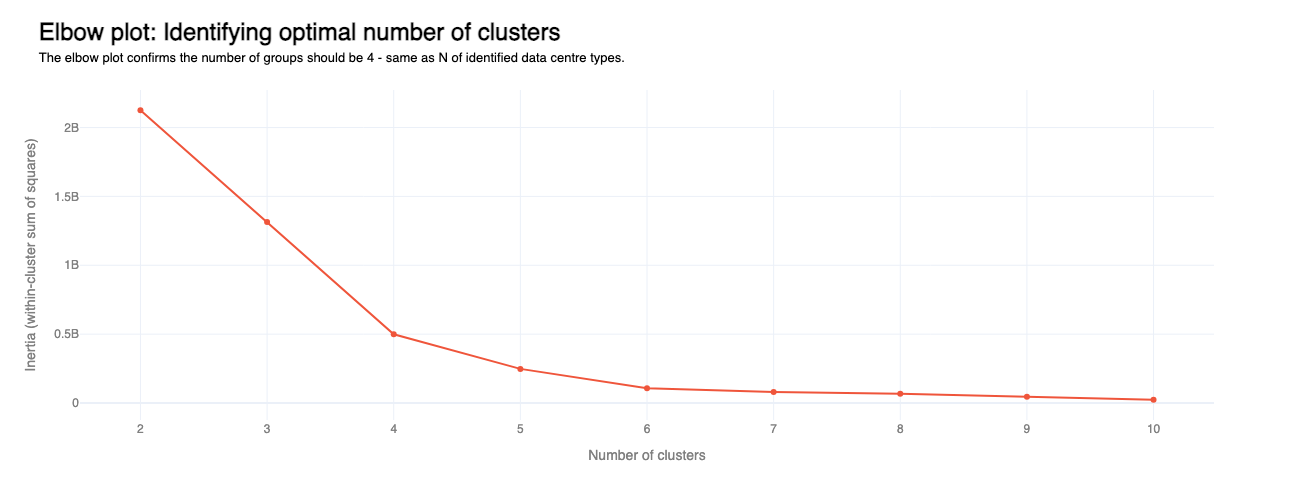

In [400]:
# ____________________________________________________________________________________________________________
# Step 1 - Segment the data by size using Jenks natural breaks, because our data can have unequal number of datapoints in each group
# https://pbpython.com/natural-breaks.html
#________________________________________________________________________________________________________________________________________________________
data_sizes_no_na = data_ldn_exstg.dropna(subset=["b8_gia_sqm"])

# ___________________________________________________________________________________________________________
# elbow plot
#____________________________________________________________________________________________________________

X = data_sizes_no_na[["b8_gia_sqm"]]  # must be 2D
inertias = []
k_values = list(range(2, 11))  # try k = 2 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(x=k_values,y=inertias,mode="lines+markers",name="Inertia", 
    line=dict(color=px.colors.qualitative.Plotly[1]),
    marker=dict(color=px.colors.qualitative.Plotly[1]))
             )
fig.update_layout(
    width=1000,
    height=500,
    template="plotly_white",
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Elbow plot: Identifying optimal number of clusters"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "The elbow plot confirms the number of groups should be 4 - same as N of identified data centre types."
            "</span><br>"
        ),
        x=0.03,xanchor="left",
        y=0.92,yanchor="top",
    ),
    margin=dict(t=90),
    legend=dict(font=dict(color=labels_colour)),
    xaxis_title="Number of clusters",
    yaxis_title="Inertia (within-cluster sum of squares)",
)

# Axis labels
fig.update_xaxes(
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.update_yaxes(
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.show()

In [401]:
sizes_col = data_sizes_no_na["b8_gia_sqm"].values #taking a non-null subset
breaks = jenkspy.jenks_breaks(sizes_col, n_classes=4) #taking 4 classes to match existing domain knowledge - number of DC types
sizes_ful_col = data_ldn_exstg["b8_gia_sqm"].values #now taking a full column

gia_labels = ["Small", "Medium", "Large", "Massive"]

#creating a new column to code in gia group
data_ldn_exstg["B8_gia_group"] = pd.cut(
    data_ldn_exstg["b8_gia_sqm"],
    bins=breaks,
    labels=gia_labels,
    include_lowest=True
)

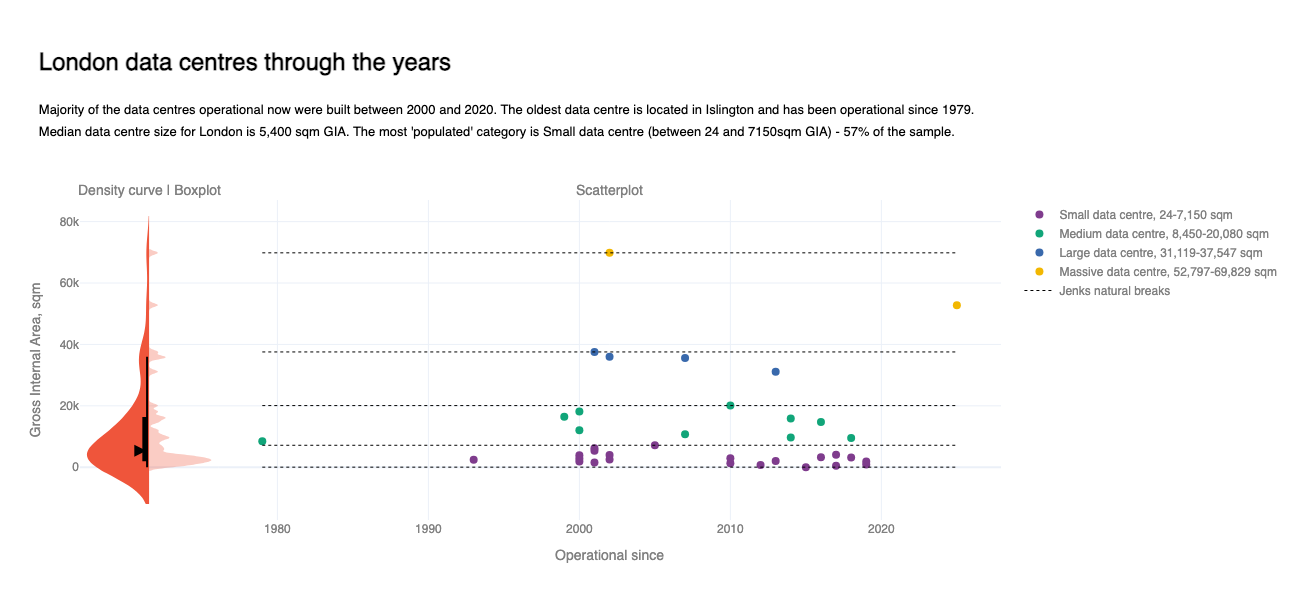

In [402]:
#______________________________________
# Build subplots
#______________________________________

notes_colour = "black"
labels_colour = "grey"

df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "data_centre_since"]).copy()
# df = df.sort_values(by="data_centre_since", ascending=True)

cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
customdata = df[cols_to_show].to_numpy()
base_color = px.colors.qualitative.Plotly[1]
# base_color = "grey"
colors = px.colors.qualitative.Bold

main_x = df["data_centre_since"]
main_y = df["b8_gia_sqm"]

median_value = main_y.median()

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    column_widths=[0.15, 0.85],
    horizontal_spacing=0.00,
    subplot_titles=["Density curve | Boxplot", "Scatterplot"],
)
fig.update_annotations(
    font=dict(
        size=14,                 # match your axis label size (adjust if needed)
        color=labels_colour      # same as axis labels
    )
)

#______________________________________
# Scatterplot
#______________________________________
bands_sorted = sorted(df["B8_gia_group"].dropna().unique())

for i, band in enumerate(gia_labels):
    df_band = df[df["B8_gia_group"] == band]

    fig.add_trace(go.Scatter(
        x=df_band["data_centre_since"],
        y=df_band["b8_gia_sqm"],
        mode="markers",
        marker=dict(
            size=8,
            color=colors[i % len(colors)],
        ),
        customdata=df_band[cols_to_show].to_numpy(),
        hovertemplate=hovertemplate,
        name=f"{band} data centre, {int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].min()):,}-{int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].max()):,} sqm",
    ), row=1, col=2)

# Breaks
for i, b in enumerate(breaks):
    fig.add_trace(go.Scatter(
        x=[main_x.min(), main_x.max()],   # span YEARS
        y=[b, b],                         # horizontal line at GIA break
        mode="lines",
        line=dict(color="black", width=1, dash="dot"),
        name="Jenks natural breaks" if i == 0 else None,
        showlegend=True if i == 0 else False,
        hovertemplate=(
            f"Jenks break<br>"
            f"GIA boundary: {b:,.0f} sqm<br>"
            "<extra></extra>"
        ),
        hoverinfo="text"
    ), row=1, col=2)

#______________________________
# Density curves
#______________________________________

# bottom
fig.add_trace(go.Violin(
    y=main_y,
    x0=1,
    orientation="v", 
    side="positive", 
    points=False, 
    bandwidth=600, 
    width=45, 
    line=dict(width=0), 
    fillcolor=make_transparent(base_color, alpha=0.3), 
    showlegend=False, 
    hoverinfo="skip" 
), row=1, col=1)

# top
fig.add_trace(go.Violin(
    y=main_y,
    orientation="v",
    side="negative",
    width=45,
    bandwidth=6000,
    line=dict(width=0),
    points=False,
    box_visible=True,
    box_fillcolor="black",
    box_line=dict(color="black", width=2),
    box_width=0.12,
    fillcolor=base_color,
    showlegend=False,
    hoverinfo="skip",
), row=1, col=1)

# median
fig.add_scatter(
    x=[0],
    y=[median_value],
    mode='markers',
    marker=dict(symbol='arrow-right', color='black', size=12),
    showlegend=False,
    hoverinfo="skip"
)

#______________________________________
# Layout updates - adding title and subtitle notes
#______________________________________
fig.update_layout(
    width=1000,
    height=600,
    template="plotly_white",
    # paper_bgcolor="#f9f4ed",
    # plot_bgcolor="#f9f4ed",
    title=dict(
       text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "London data centres through the years"
            "</span><br><br>"
        
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Majority of the data centres operational now were built between 2000 and 2020. "
            f"The oldest data centre is located in {df.loc[main_x.idxmin(), 'lpa_name']} and has been operational since {int(main_x.min())}. "
            "</span><br>"
        
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;margin-bottom:0px;'>"
            f"Median data centre size for London is {median_value:,.0f} sqm GIA. "
            f"The most 'populated' category is {df["B8_gia_group"].value_counts().idxmax()} data centre (between {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].min())} and {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].max())}sqm GIA) - {(df["B8_gia_group"].value_counts().max() / (len(df["B8_gia_group"].notna()) / 100)):,.0f}% of the sample."
            "</span><br>"

        ),

        x=0.03,
        xanchor="left",
        y=0.92,
        yanchor="top",
    ),
    margin=dict(t=200),
    legend=dict(
        font=dict(color=labels_colour)
    )
)

# Axis labels
fig.update_xaxes(
    title_text="Operational since",
    row=1, col=2,
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.update_yaxes(
    title_text="Gross Internal Area, sqm",
    row=1, col=1,
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.update_yaxes(showticklabels=False, row=1, col=2)
fig.update_xaxes(showticklabels=False, row=1, col=1)


fig.show()

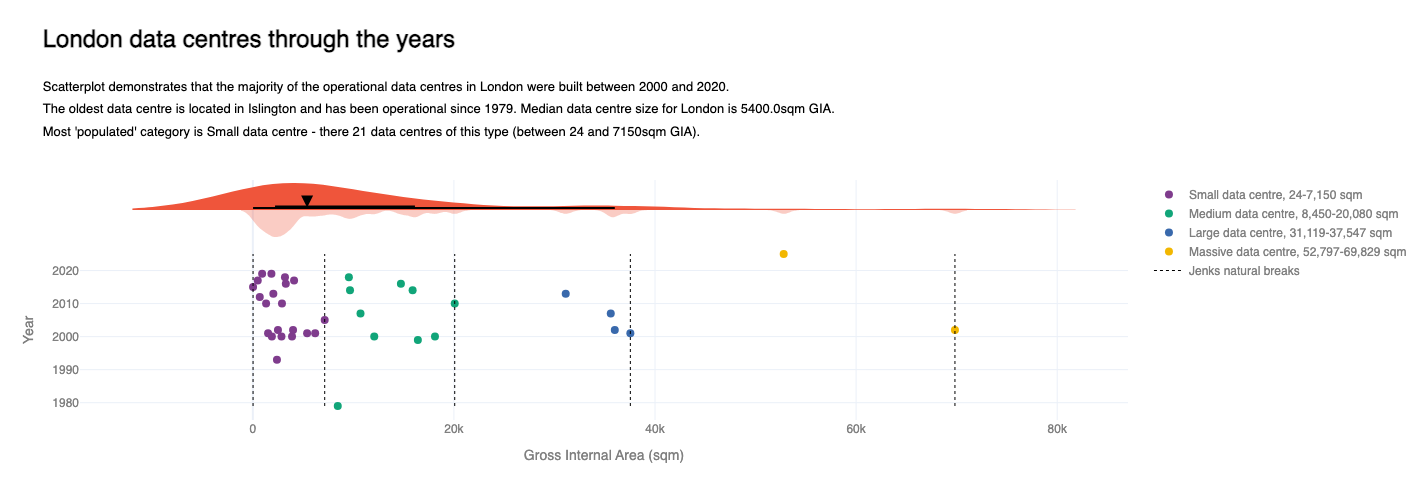

In [257]:
# #______________________________________
# # Build subplots
# #______________________________________

# notes_colour = "black"
# labels_colour = "grey"

# df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "data_centre_since"]).copy()
# # df = df.sort_values(by="data_centre_since", ascending=True)

# cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
# customdata = df[cols_to_show].to_numpy()
# base_color = px.colors.qualitative.Plotly[1]
# # base_color = "grey"
# colors = px.colors.qualitative.Bold

# main_x = df["b8_gia_sqm"]
# main_y = df["data_centre_since"]

# median_value = main_x.median()

# fig = make_subplots(
#     rows=2,
#     cols=1,
#     shared_xaxes=True,
#     row_heights=[0.25, 0.75],
#     vertical_spacing=0.00
# )

# #______________________________________
# # Scatterplot
# #______________________________________
# bands_sorted = sorted(df["B8_gia_group"].dropna().unique())

# for i, band in enumerate(gia_labels):
#     df_band = df[df["B8_gia_group"] == band]

#     fig.add_trace(go.Scatter(
#         x=df_band["b8_gia_sqm"],
#         y=df_band["data_centre_since"],
#         mode="markers",
#         marker=dict(
#             size=8,
#             color=colors[i % len(colors)],
#         ),
#         customdata=df_band[cols_to_show].to_numpy(),
#         hovertemplate=hovertemplate,
#         name=f"{band} data centre, {int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].min()):,}-{int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].max()):,} sqm",
#     ), row=2, col=1)

# # Breaks
# for i, b in enumerate(breaks):
#     fig.add_trace(go.Scatter(
#         x=[b, b],
#         y=[main_y.min(), main_y.max()],
#         mode="lines",
#         line=dict(color="black", width=1, dash="dot"),
#         name="Jenks natural breaks" if i == 0 else None,
#         showlegend=True if i == 0 else False,
#         hovertemplate=(
#             f"Jenks break<br>"
#             f"GIA boundary: {b:,.0f} sqm<br>"
#             "<extra></extra>"
#         ),
#         hoverinfo="text"
#     ), row=2, col=1)

# #______________________________
# # Density curves
# #______________________________________

# # bottom
# fig.add_trace(go.Violin(
#     x=main_x,
#     y0=1,
#     orientation="h", 
#     side="negative", 
#     points=False, 
#     bandwidth=600, 
#     width=45, 
#     line=dict(width=0), 
#     fillcolor=make_transparent(base_color, alpha=0.3), 
#     showlegend=False, 
#     hoverinfo="skip" 
# ), row=1, col=1)

# # top
# fig.add_trace(go.Violin(
#     x=main_x,
#     orientation="h",
#     side="positive",
#     width=45,
#     bandwidth=6000,
#     line=dict(width=0),
#     points=False,
#     box_visible=True,
#     box_fillcolor="black",
#     box_line=dict(color="black", width=2),
#     box_width=0.12,
#     fillcolor=base_color,
#     showlegend=False,
#     hoverinfo="skip",
# ), row=1, col=1)

# # median
# fig.add_scatter(
#     x=[median_value],
#     # y=[0],
#     mode='markers',
#     marker=dict(symbol='arrow-down', color='black', size=12),
#     showlegend=False,
#     y0=3,
# )

# #______________________________________
# # Layout updates - adding title and subtitle notes
# #______________________________________
# fig.update_layout(
#     width=1000,
#     height=500,
#     template="plotly_white",

#     title=dict(
#        text=(
#             f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:4px;'>"
#             "London data centres through the years"
#             "</span><br><br>"
        
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#             "Scatterplot demonstrates that the majority of the operational data centres in London were built between 2000 and 2020."
#             "</span><br>"
        
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
#             f"The oldest data centre is located in {df.loc[main_y.idxmin(), 'lpa_name']} and has been operational since {int(main_y.min())}. "
#             f"Median data centre size for London is {median_value}sqm GIA."
#             "</span><br>"

#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
#             f"Most 'populated' category is {df["B8_gia_group"].value_counts().idxmax()} data centre - there {df["B8_gia_group"].value_counts().max()} data centres of this type (between {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].min())} and {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].max())}sqm GIA)."
#             "</span><br>"
#         ),

#         x=0.03,
#         xanchor="left",
#         y=0.95,
#         yanchor="top",
#     ),
#     margin=dict(t=180),

#     legend=dict(
#         font=dict(color=labels_colour)
#     )
# )

# # Axis labels
# fig.update_yaxes(title_text="Year", row=2, col=1, title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
# fig.update_xaxes(title_text="Gross Internal Area (sqm)", row=2, col=1, title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
# fig.update_yaxes(showticklabels=False, row=1, col=1)

# fig.show()

In [214]:
# ____________________________________________________
# Filtered by availability of total/daily ration
# ____________________________________________________
data_ldn_total_daily = data_ldn.dropna(subset=["total/day ratio"])

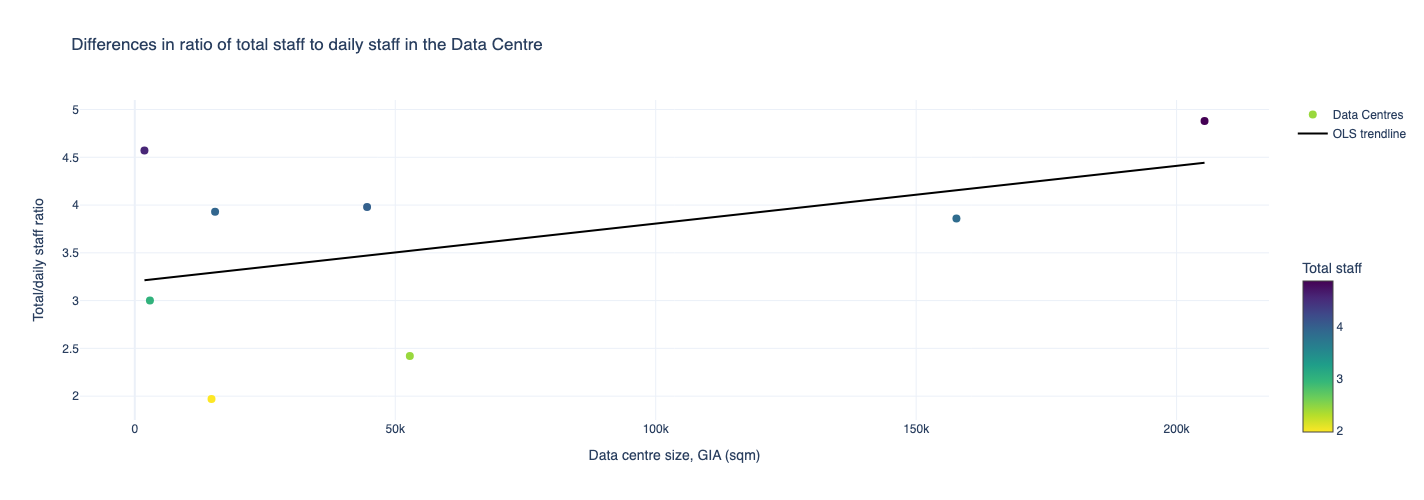

In [30]:
# Columns to show in hover
cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
customdata = data_ldn_total_daily[cols_to_show].to_numpy()

hovertemplate = "<br>".join([
    f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
])

# X and Y
x = data_ldn_total_daily["b8_gia_sqm"].values
y = data_ldn_total_daily["total/day ratio"].values

# OLS fit (y = m*x + c)
m, c = np.polyfit(x, y, 1)

# Trendline values
x_trend = np.linspace(x.min(), x.max(), 100)
y_trend = m * x_trend + c

# -------------------------------------
# Build Plot
# -------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_ldn_total_daily["b8_gia_sqm"],
    y=data_ldn_total_daily["total/day ratio"],
    mode="markers",
    marker=dict(
        size=8,
        color=data_ldn_total_daily["total/day ratio"],
        colorscale="Viridis_r",
        showscale=True,
        colorbar=dict(title="Total staff", len=0.6, xanchor="left", yanchor="top", y=0.53)
    ),
    customdata=customdata,
    hovertemplate=hovertemplate,
    name="Data Centres"
))

# OLS trendline
fig.add_trace(go.Scatter(
    x=x_trend,
    y=y_trend,
    mode="lines",
    line=dict(color="black", width=2),
    name="OLS trendline"
))

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    title="Differences in ratio of total staff to daily staff in the Data Centre",
    xaxis_title="Data centre size, GIA (sqm)",
    yaxis_title="Total/daily staff ratio",
    width=1000,
    height=500,
    template="plotly_white"
)

fig.show()

In [ ]:
I am determining the clusters of data centre size and total/daily ratio to identify an average ratio per size band. 

In [31]:
len(data_ldn)

65

In [17]:
print(f"B8 use GIA range is {data_ldn["b8_gia_sqm"].max() - data_ldn["b8_gia_sqm"].min()} sqm.")

B8 use GIA range is 205341.0 sqm.


I will be using k-neighbours clustering to identify types of data centres by size using b8_gia_sqm clolumn – Gross Internal Area of the B8 use within the data centre block. There are 7 null values in this column, and imputation would not result in reliable numbers since they are not dependent on any other known variable. Therefore, for this step, I will work on a subset without NA values.

I will be using several variables in the k-means, and first i need to fill in the missing values in the employees' column.

1. A few of the DC entries have the total and daily staff numbers included within the planning application or on the website. I am using the average ratio of 

In [ ]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df_reduced_imputed)

df_scaled = pd.DataFrame(
    scaled_array,
    columns=cols_for_clustering,
    index=df_school_london.index
)

df_scaled.describe().T

In [238]:
# # Columns to show in hover
# cols_to_show = [
#     "id", "current_occupier", "lpa_name",
#     "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte"
# ]
# customdata = data_ldn_date[cols_to_show].to_numpy()

# hovertemplate = "<br>".join([
#     f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
# ])

# # -------------------------------------
# # Build Plot
# # -------------------------------------
# fig = go.Figure()

# # --- Scatter plot ---
# fig.add_trace(go.Scatter(
#     x=data_ldn_date["data_centre_since"],
#     y=data_ldn_date["b8_gia_sqm"],
#     mode="markers",
#     marker=dict(
#         size=8,
#         color=data_ldn_date["b8_total_staff_fte"],
#         colorscale="Viridis_r",
#         showscale=True,
#         colorbar=dict(title="Total staff")
#     ),
#     customdata=customdata,
#     hovertemplate=hovertemplate,
#     name="Data Centre"
# ))

# # -------------------------------------
# # Half violin on top (right side only)
# # -------------------------------------
# y_top = data_ldn_date["b8_gia_sqm"].max() * 1.05

# fig.add_trace(go.Violin(
#     x=data_ldn_date["data_centre_since"],
#     y=[y_top] * len(data_ldn_date),     # fixed vertical position
#     orientation="h",
#     side="positive",                    # right half only
#     width=y_top * 0.08,                 # visual thickness
#     points=False,
#     line=dict(width=0),
#     fillcolor="rgba(80,80,80,0.4)",
#     showlegend=False,
# ))

# # -------------------------------------
# # Layout
# # -------------------------------------
# fig.update_layout(
#     title="Growth of data centre size over time",
#     xaxis_title="Year",
#     yaxis_title="Gross Internal Area (sqm)",
#     width=1000,
#     height=600,
#     template="plotly_white"
# )

# # Make room for the violin
# fig.update_yaxes(range=[0, y_top * 1.15])

# fig.show()


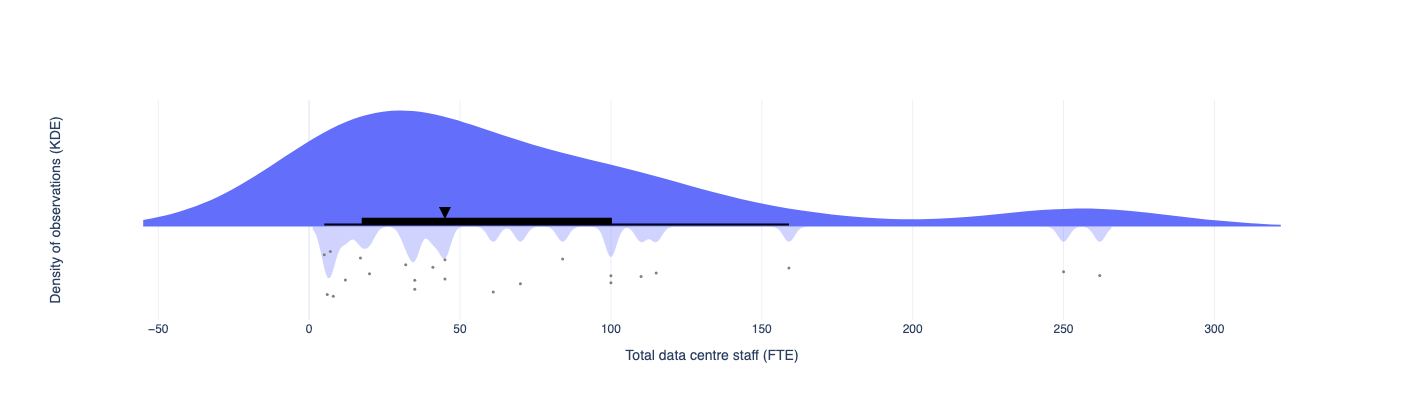

In [115]:
# -------------------------------------
# Set variables
# -------------------------------------
value_col = 'b8_total_staff_fte'
cols_to_show = ['id', 'lpa_name', 'data_centre_since', 'b8_gia_sqm', 'b8_total_staff_fte']

# Drop missing
df = data_ldn_date.dropna(subset=[value_col])

# -------------------------------------
# Compute median
# -------------------------------------
median_value = df[value_col].median()

# -------------------------------------
# Colour
# -------------------------------------
base_color = px.colors.qualitative.Plotly[0]

# Helper: convert rgb/hex to transparent rgba
def make_transparent(color, alpha=0.3):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

# -------------------------------------
# Build figure
# -------------------------------------
fig = go.Figure()

subset_customdata = df[cols_to_show].to_numpy()

hovertemplate = "<br>".join(
    [f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)]
)

# -------------------------------------
# Bottom transparent half
# -------------------------------------
fig.add_trace(go.Violin(
    x=df[value_col],
    orientation='h',
    side='negative',
    points=False,
    bandwidth=1.9,
    width=0.4,
    line=dict(width=0),
    fillcolor=make_transparent(base_color, alpha=0.3),
    showlegend=False,
    customdata=subset_customdata,
    hovertemplate=hovertemplate,
    y0=1, 
))

# -------------------------------------
# Upper solid half + points + box
# -------------------------------------
fig.add_trace(go.Violin(
    x=df[value_col],
    orientation='h',
    side='positive',
    width=0.9,
    bandwidth=30,
    line=dict(width=0),
    points="all",
    jitter=0.3,
    pointpos=-0.4,
    marker=dict(color='grey', size=3, opacity=1),
    box_visible=True,
    box_fillcolor='black',
    box_line=dict(color='black', width=2),
    box_width=0.1,
    fillcolor=base_color,
    showlegend=False,
    customdata=subset_customdata,
    hovertemplate=hovertemplate,
))

# -------------------------------------
# Median arrow
# -------------------------------------
fig.add_scatter(
    x=[median_value],
    # y=[0],
    mode='markers',
    marker=dict(symbol='arrow-down', color='black', size=12),
    showlegend=False,
    y0=1.03,
)

# -------------------------------------
# Layout (with density label)
# -------------------------------------
fig.update_layout(
    violinmode='overlay',
    width=1000,
    height=400,
    xaxis_title="Total data centre staff (FTE)",
    yaxis=dict(
        showticklabels=False,
        title="Density of observations (KDE)",
        ticks="",             
        showgrid=False,
        zeroline=False,            
    ),
    template='plotly_white'
)


fig.show()

In [117]:
# data_ldn_date

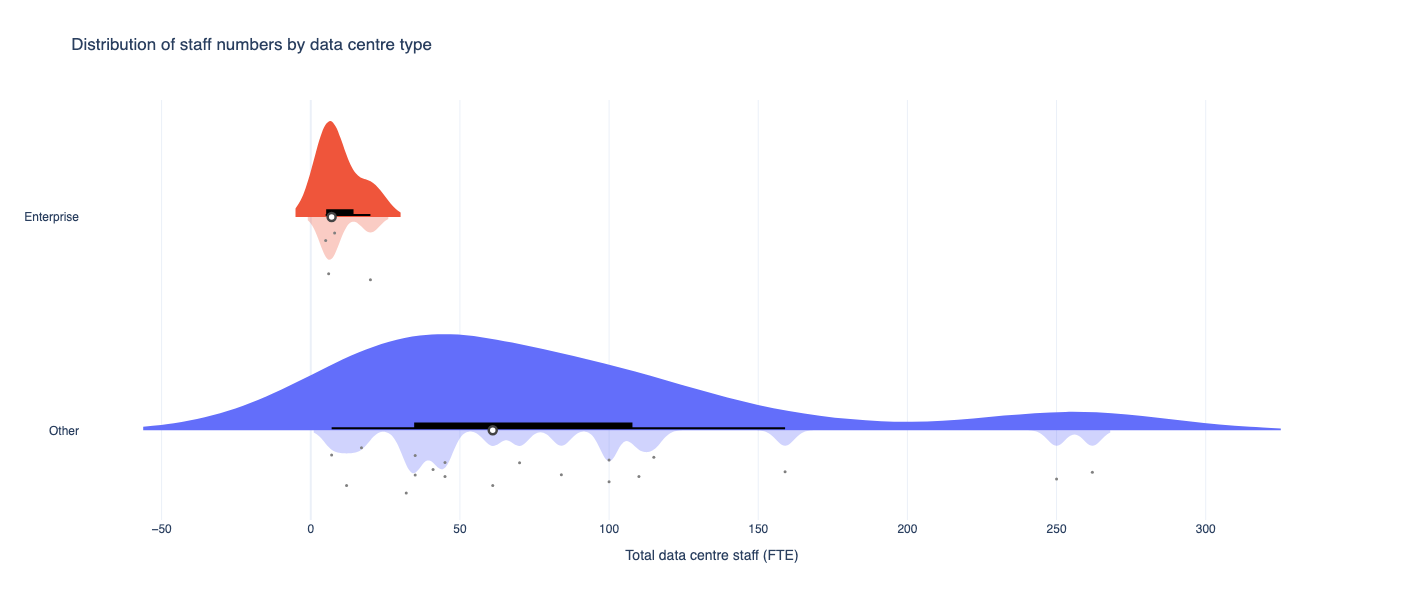

In [186]:
# -------------------------------------
# Explicit categories (boolean)
# -------------------------------------
categories = [False, True]

palette = px.colors.qualitative.Plotly
color_map = {
    False: palette[0],
    True: palette[1],
}

# Helper function to convert hex or rgb to rgba with desired alpha
def make_transparent(color, alpha=0.2):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

# -------------------------------------
# Build figure
# -------------------------------------
fig = go.Figure()

for cat in categories:
    subset = data_ldn_date[data_ldn_date['enterprise'] == cat]

    # Left half-violin (transparent)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),                     # ← critical
        x=subset['b8_total_staff_fte'],
        orientation='h',
        side='negative',
        points=False,
        bandwidth=3,
        width=0.4,
        line=dict(width=0),
        fillcolor=make_transparent(color_map[cat], alpha=0.3),
        showlegend=False,
    ))

    # Right half-violin (solid + points + box)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),                     # ← critical
        x=subset['b8_total_staff_fte'],
        orientation='h',
        side='positive',
        width=0.9,
        line=dict(width=0),
        points="all",
        jitter=0.3,
        pointpos=-0.4,
        marker=dict(color='grey', size=3),
        box_visible=True,
        box_fillcolor='black',
        box_line=dict(color='black', width=2),
        box_width=0.1,
        fillcolor=color_map[cat],
        showlegend=False,
    ))

# -------------------------------------
# Median arrows
# -------------------------------------
medians = (
    data_ldn_date
    .groupby('enterprise')['b8_total_staff_fte']
    .median()
    .reset_index()
)

fig.add_scatter(
    x=medians['b8_total_staff_fte'],
    y=medians['enterprise'],
    mode='markers',
    marker=dict(
        symbol='circle',   # horizontal line
        color='white',
        size=8,
        line=dict(width=2.5),
    ),
    showlegend=False,
)

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    title="Distribution of staff numbers by data centre type",
    violinmode='overlay',
    width=1000,
    height=600,
    xaxis=dict(
        title="Total data centre staff (FTE)",
        # range=[0, None],       
    ),
    yaxis=dict(
        title=None,
        tickvals=[False, True],  
        ticktext=["Other", "Enterprise"],  # labels shown
        categoryorder="array",
        categoryarray=[False, True],  # explicit order
        showgrid=False,
    ),
    template='plotly_white',
)

fig.show()

In [14]:
data_ldn_size["b8_gia_sqm"].describe()

count        58.000000
mean      22278.826934
std       37393.369201
min           0.027000
25%        2568.750000
50%        9001.500000
75%       26506.000000
max      205365.000000
Name: b8_gia_sqm, dtype: float64

In [ ]:
# Get unique categories and assign a color palette
categories = england_filtered_regression['gor_name_'].unique()
palette = px.colors.qualitative.Plotly  # built-in Plotly qualitative palette
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}

# Helper function to convert hex or rgb to rgba with desired alpha
def make_transparent(color, alpha=0.2):
    if color.startswith("rgb"):  # already rgb string
        return color.replace(")", f", {alpha})")
    elif color.startswith("#"):  # hex to rgba
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    else:
        return color  # fallback

fig = go.Figure()

for cat in categories:
    subset = england_filtered_regression[england_filtered_regression['gor_name_'] == cat]
    
    # Left half-violin (negative side) with transparency
    fig.add_trace(go.Violin(
        y=subset['gor_name_'],
        x=subset['PTFSM6CLA1A'],
        orientation='h',
        side='negative',
        points=False,
        bandwidth=0.5,             # smoothness for left half
        width=0.9,
        line=dict(width=0),
        # box_visible=True,
        fillcolor=make_transparent(color_map[cat], alpha=0.3),
        name=cat,
        showlegend=False
    ))
    
    # Right half-violin (positive side)
    fig.add_trace(go.Violin(
        y=subset['gor_name_'],
        x=subset['PTFSM6CLA1A'],
        orientation='h',
        side='positive',
        width=0.9,
        line=dict(width=0),
        points="all",
        jitter=0.3,
        pointpos=-0.4,
        marker=dict(color='grey', size=2, opacity=1),
        box_visible=True,
        box_fillcolor='black',
        box_line=dict(color='black', width=2),
        box_width=0.2,
        fillcolor=color_map[cat],
        name=cat,
        showlegend=False
    ))

# Overlay median points
medians = england_filtered_regression.groupby('gor_name_')['PTFSM6CLA1A'].median().reset_index()
fig.add_scatter(
    x=medians['PTFSM6CLA1A'],
    y=medians['gor_name_'],
    mode='markers',
    marker=dict(symbol='arrow', color='black', size=8),
    showlegend=False,
)

fig.update_layout(
    violinmode='overlay',
    width=1000,
    height=800,
    xaxis_title="% Disadvantaged Pupils",
    yaxis_title="",
    template='plotly_white'
)

fig.show()